In [2]:
# Cargar librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración para gráficos
sns.set(style="whitegrid", context="talk")

# Cargar los datos (asegúrate de que la ruta sea correcta)
file_path = '../EncodedChromosomes_V3_results.csv'
data = pd.read_csv(file_path)

# Convertir la columna 'Encoded Architecture' de string a lista (si es necesario)
data['Encoded Architecture'] = data['Encoded Architecture'].apply(eval)

# Mostrar las primeras filas para confirmar la carga
data.head()


,Encoded Architecture,Loss,Accuracy,Precision,Recall,F1,Specificity
0,"[3, 0, 0, 0, 7, 0, 0, 0, 2, 0, 0, 0, 2, 0, 0, ...",0.693179,0.5,0.508970,0.652431,0.571840,0.370565
1,"[0, 26, 1, 0, 8, 1, 2, 0, 2, 0, 0, 0, 4, 18, 0...",0.695351,0.5,0.499303,0.470434,0.484438,0.528252
2,"[5, 0, 0, 0, 7, 0, 0, 0, 4, 390, 0, 0, 7, 0, 0...",0.693323,0.5,0.496341,0.490145,0.493223,0.502628
3,"[0, 28, 0, 0, 5, 0, 0, 0, 7, 0, 0, 0, 7, 0, 0,...",0.703990,0.5,0.492084,0.490145,0.491113,0.494087
4,"[4, 296, 0, 0, 1, 4, 0, 0, 1, 4, 0, 0, 7, 0, 0...",0.693923,0.5,0.516696,0.579501,0.546299,0.457950


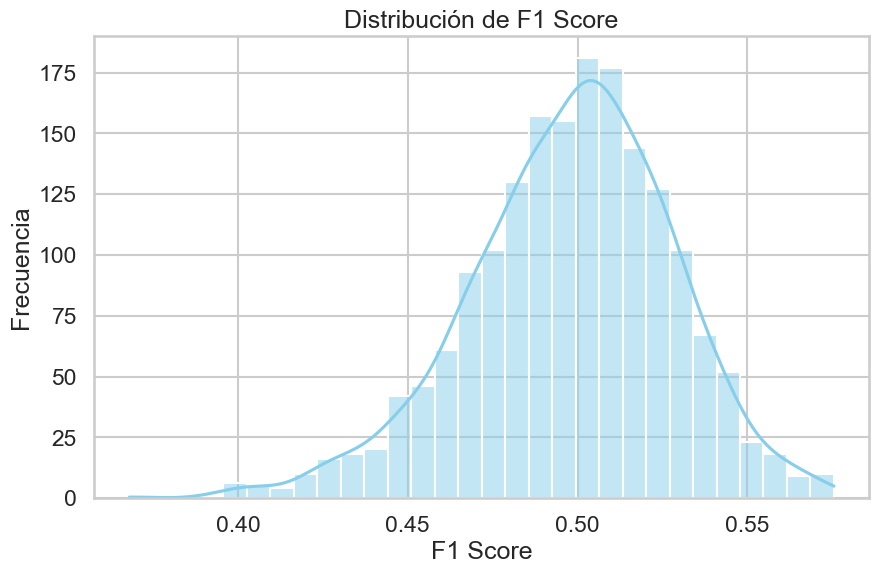

Estadísticas descriptivas del F1 Score:
count    1777.000000
mean        0.497945
std         0.030036
min         0.368067
25%         0.480027
50%         0.500332
75%         0.518519
max         0.575472
Name: F1, dtype: float64


In [3]:
# Análisis de la distribución del F1 Score
plt.figure(figsize=(10,6))
sns.histplot(data['F1'], bins=30, kde=True, color='skyblue')
plt.title('Distribución de F1 Score')
plt.xlabel('F1 Score')
plt.ylabel('Frecuencia')
plt.show()

# Estadísticas descriptivas
print("Estadísticas descriptivas del F1 Score:")
print(data['F1'].describe())


In [4]:
# Si dispones de la columna 'SynFlow', analiza su distribución y correlación con F1 Score
if 'SynFlow' in data.columns:
    plt.figure(figsize=(10,6))
    sns.histplot(data['SynFlow'], bins=30, kde=True, color='lightgreen')
    plt.title('Distribución de SynFlow')
    plt.xlabel('SynFlow')
    plt.ylabel('Frecuencia')
    plt.show()
    
    # Gráfico de dispersión entre SynFlow y F1 Score
    plt.figure(figsize=(8,6))
    sns.scatterplot(x='SynFlow', y='F1', data=data, alpha=0.6)
    sns.regplot(x='SynFlow', y='F1', data=data, scatter=False, color='red')
    plt.title('Correlación entre SynFlow y F1 Score')
    plt.xlabel('SynFlow')
    plt.ylabel('F1 Score')
    plt.show()
    
    # Calcular correlación de Pearson
    from scipy.stats import pearsonr
    corr, p_value = pearsonr(data['SynFlow'], data['F1'])
    print(f"Correlación de Pearson: {corr:.4f} (p-valor: {p_value:.4f})")


C:\Users\herna\AppData\Local\Temp\ipykernel_14456\3469545538.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='tipo', data=layer_types, palette='viridis')


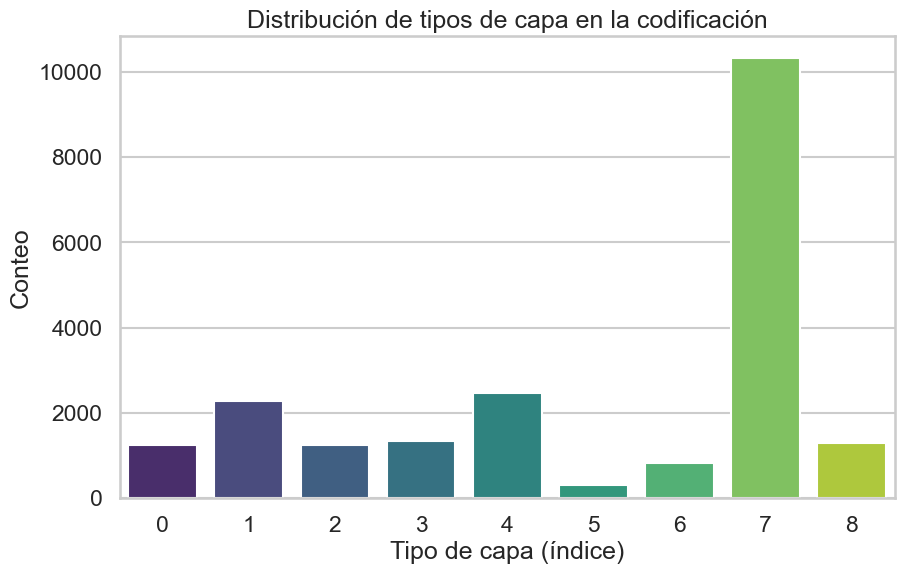

In [5]:
# Expandir la columna 'Encoded Architecture' en un DataFrame
encoded_df = pd.DataFrame(data['Encoded Architecture'].tolist())
encoded_df.columns = [f'param_{i}' for i in range(encoded_df.shape[1])]

# Ver la distribución del parámetro que representa el tipo de capa (por ejemplo, cada 4 columnas se define un layer)
layer_types = encoded_df.iloc[:, ::4]  # Tomamos cada 4 columnas
layer_types = layer_types.melt(var_name='layer', value_name='tipo')
plt.figure(figsize=(10,6))
sns.countplot(x='tipo', data=layer_types, palette='viridis')
plt.title('Distribución de tipos de capa en la codificación')
plt.xlabel('Tipo de capa (índice)')
plt.ylabel('Conteo')
plt.show()
